# Loading the libraries

In [169]:
import numpy as np
import scipy.io.wavfile as wav
from scipy.signal import butter, lfilter, iirnotch, find_peaks, filtfilt
import matplotlib.pyplot as plt
import IPython.display as ipd # For playing audio in a Notebook

# Loading the audio

In [170]:
# Load the audio
sample_rate, data = wav.read('task5_1.wav')

data = data.astype(np.float32)

# Play the audio
ipd.Audio(data,rate=sample_rate)

# Plotting the frequency

Found 263 distinct noise spikes to remove!


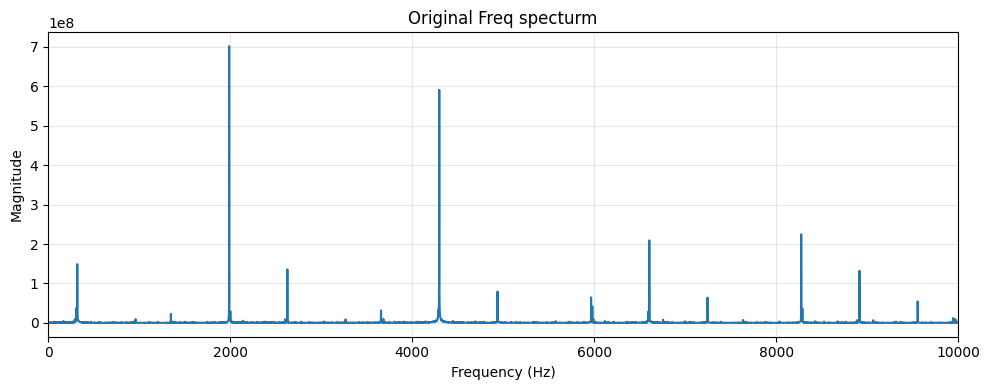

In [ ]:
peak_frequencies = []

def plot_frequency_spectrum(data: np.ndarray, sample_rate: int, title: str = "Frequency Spectrum"):
    """
    Computes and plots the Fast Fourier Transform (FFT) of the audio data 
    to visually identify noise spikes.
    """
    n = len(data)
    # Compute the FFT
    yf = np.fft.fft(data)
    # Compute the corresponding frequencies
    xf = np.fft.fftfreq(n, 1 / sample_rate)
    
    # Only plot the positive frequencies
    positive_freqs = xf[:n//2]
    magnitude = np.abs(yf[:n//2])

    mean_magnitude = np.mean(magnitude)
    std_magnitude = np.std(magnitude)

    dynamic_threshold = mean_magnitude + (0.001 * std_magnitude)

    peaks, _ = find_peaks(magnitude, height=dynamic_threshold, distance=100)

    exact_peak_freqs = positive_freqs[peaks]
    print(f"Found {len(exact_peak_freqs)} distinct noise spikes to remove!")

    plt.figure(figsize=(10, 4))
    plt.plot(positive_freqs, magnitude, color='#1f77b4')
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, max(5000, min(sample_rate/2, 10000))) # Focus on relevant audio range
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return exact_peak_freqs

peak_frequencies = plot_frequency_spectrum(data, sample_rate, "Original Freq specturm")

# Remove the highest frequency

Removed freq: 5.4
Removed freq: 68.9
Removed freq: 121.7
Removed freq: 169.2
Removed freq: 217.5
Removed freq: 267.6
Removed freq: 319.6
Removed freq: 370.6
Removed freq: 418.9
Removed freq: 470.8
Removed freq: 558.5
Removed freq: 657.9
Removed freq: 722.3
Removed freq: 809.2
Removed freq: 860.2
Removed freq: 959.6
Removed freq: 1110.8
Removed freq: 1198.5
Removed freq: 1297.9
Removed freq: 1348.9
Removed freq: 1400.8
Removed freq: 1449.2
Removed freq: 1500.2
Removed freq: 1587.0
Removed freq: 1651.5
Removed freq: 1750.8
Removed freq: 1837.7
Removed freq: 1890.5
Removed freq: 1939.7
Removed freq: 1988.9
Removed freq: 2041.7
Removed freq: 2089.2
Removed freq: 2140.2
Removed freq: 2185.0
Removed freq: 2239.6
Removed freq: 2390.8
Removed freq: 2477.7
Removed freq: 2580.6
Removed freq: 2628.9
Removed freq: 2679.9
Removed freq: 2780.2
Removed freq: 2867.0
Removed freq: 3030.8
Removed freq: 3117.7
Removed freq: 3168.7
Removed freq: 3268.9
Removed freq: 3319.9
Removed freq: 3420.2
Removed fre

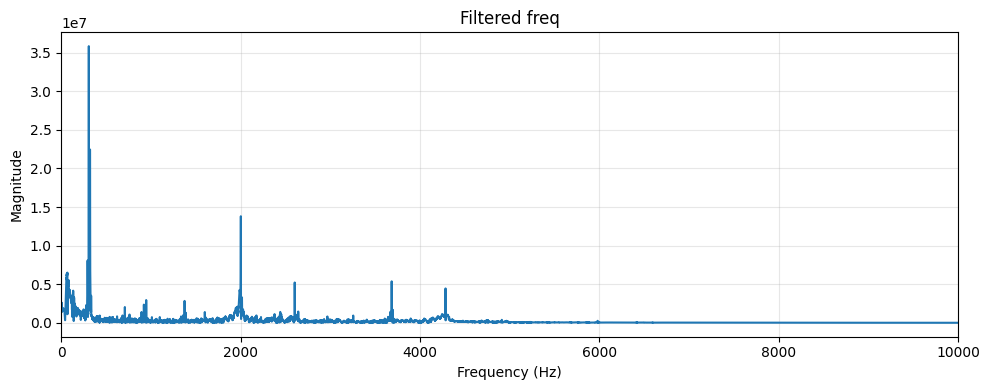

In [200]:
def apply_notch_filter(data: np.ndarray, sample_rate: int, target_freq: float, quality_factor: float = 100.0) -> np.ndarray:
    # Design the notch filter
    b, a = iirnotch(target_freq, quality_factor, sample_rate)
    # Apply the filter to the data
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def apply_speech_bandbass(data: np.ndarray, sample_rate: int, lowcut: float = 50.0, highcut: float = 5000.0) -> np.ndarray:
    nyq = 0.5 * sample_rate
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(5, [low, high], btype='band')
    return filtfilt(b, a, data)

filtered_data = data.copy()

filtered_data = apply_speech_bandbass(filtered_data, sample_rate)

for freq in peak_frequencies:
    print(f"Removed freq: {freq:.1f}")
    filtered_data = apply_notch_filter(filtered_data, sample_rate, freq)

plot_frequency_spectrum(filtered_data, sample_rate, "Filtered freq")



filtered_data = filtered_data / np.max(np.abs(filtered_data))


ipd.Audio(filtered_data,rate=sample_rate)


This is the best I could do tbh

The text I can hear is: "رايح الكلية"